# LAB 08: Aprendizaje por Refuerzo - Q-Learning
## Entorno: Blackjack (Gymnasium)
# **Grupo #7**
GIT:https://github.com/Richi-20/InteligeciaArtificial-RCC/tree/main/laboratorio8

**Integrantes:**
- Mancilla Rodríguez Ulises Jesús
- Cuiza Muraña Ramiro David
- Chavez Cano Richard

**Objetivo:** Implementar y entrenar un agente de Q-Learning para jugar Blackjack de manera óptima.

**Contenido del laboratorio:**
1. Introducción al entorno Blackjack
2. Implementación del algoritmo Q-Learning
3. Entrenamiento del agente con estrategia epsilon-greedy
4. Visualización de resultados y análisis de rendimiento
5. Evaluación y comparación con estrategias base
6. Análisis de la política aprendida

**Conceptos clave:**
- Q-Learning (Temporal Difference Learning)
- Exploración vs Explotación (epsilon-greedy)
- Tabla Q (función valor acción-estado)
- Ecuación de Bellman
- Política óptima

In [ ]:
import gymnasium as gym
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm  # Para mostrar barras de progreso durante el entrenamiento

## 1. Entendiendo el Entorno Blackjack

**Reglas del juego:**
- El objetivo es obtener cartas que sumen 21 o lo más cerca posible sin pasarse
- Las cartas numéricas valen su número, las figuras valen 10, y el A vale 1 u 11
- El jugador puede "pedir carta" (hit) o "plantarse" (stick)
- Si el jugador se pasa de 21, pierde inmediatamente

**Espacio de observación (estado):**
- Suma actual de las cartas del jugador (4-31)
- Carta visible del dealer (1-10)
- Si el jugador tiene un As utilizable (0 o 1)

**Espacio de acción:**
- 0: Plantarse (stick)
- 1: Pedir carta (hit)

**Recompensas:**
- +1: El jugador gana
- 0: Empate
- -1: El jugador pierde

In [ ]:
# Crear el entorno de Blackjack
# natural=True: Da recompensa adicional si el jugador obtiene 21 natural (Blackjack)
# sab=False: No renderiza el juego visualmente (más rápido para entrenamiento)
env = gym.make('Blackjack-v1', natural=False, sab=False)

print("Información del entorno:")
print(f"Espacio de observación: {env.observation_space}")
print(f"Espacio de acción: {env.action_space}")
print(f"Número de acciones: {env.action_space.n}")

# Ejemplo de una jugada
print("\n--- Ejemplo de una jugada ---")
observation, info = env.reset(seed=42)
print(f"Estado inicial: {observation}")
print(f"  - Suma de cartas del jugador: {observation[0]}")
print(f"  - Carta visible del dealer: {observation[1]}")
print(f"  - Tiene As utilizable: {bool(observation[2])}")

# Realizar una acción (1 = pedir carta)
observation, reward, terminated, truncated, info = env.step(1)
print(f"\nDespués de pedir carta:")
print(f"Nuevo estado: {observation}")
print(f"Recompensa: {reward}")
print(f"¿Juego terminado?: {terminated}")

Información del entorno:
Espacio de observación: Tuple(Discrete(32), Discrete(11), Discrete(2))
Espacio de acción: Discrete(2)
Número de acciones: 2

--- Ejemplo de una jugada ---
Estado inicial: (15, 2, 0)
  - Suma de cartas del jugador: 15
  - Carta visible del dealer: 2
  - Tiene As utilizable: False

Después de pedir carta:
Nuevo estado: (25, 2, 0)
Recompensa: -1.0
¿Juego terminado?: True


## 2. Implementación del Agente Q-Learning

El algoritmo Q-Learning es un método de aprendizaje por refuerzo que aprende la función de valor acción-estado `Q(s,a)`, que representa la recompensa esperada al tomar la acción a en el estado s.

**Fórmula de actualización:**

```
Q(s,a) ← Q(s,a) + α [r + γ max Q(s',a') - Q(s,a)]
```

Donde:
- α (alpha): Tasa de aprendizaje
- γ (gamma): Factor de descuento
- r: Recompensa recibida
- s: Siguiente estado

In [ ]:
# Hiperparámetros del algoritmo Q-Learning
alpha = 0.1          # Tasa de aprendizaje (learning rate) - qué tan rápido se actualiza Q
gamma = 0.9          # Factor de descuento (discount factor) - importancia de recompensas futuras
epsilon = 1.0        # Probabilidad inicial de exploración (epsilon-greedy)
epsilon_min = 0.01   # Epsilon mínimo (nunca deja de explorar completamente)
epsilon_decay = 0.99999  # Tasa de decaimiento de epsilon por episodio

# Inicializar la Q-table
q_table = {}
for player_sum in range(4, 32):  # Todas las posibles sumas del jugador
    for dealer_card in range(1, 11):  # Cartas del dealer de As(1) a 10
        for usable_ace in [0, 1]:  # Con o sin As utilizable
            q_table[(player_sum, dealer_card, usable_ace)] = [0.0, 0.0]  # [Plantarse, Pedir]

print(f"\n✓ Q-table inicializada con {len(q_table)} estados posibles")


✓ Q-table inicializada con 560 estados posibles


## 3. Función de Entrenamiento

In [ ]:
# Función ε-greedy
def choose_action(state, training=True):
    # 🔹 Solo crear entrada si el estado es válido (suma del jugador <= 21)
    if state not in q_table and state[0] <= 21:
        q_table[state] = [0, 0]

    # Si el estado no está en la tabla (suma > 21), devolver acción aleatoria
    if state not in q_table:
        return 0  # Plantarse por defecto en estados inválidos

    if training and np.random.rand() < epsilon:
        return env.action_space.sample()  # Exploración
    else:
        return np.argmax(q_table[state])  # Explotación

## 4. Entrenar el Agente

Iniciando entrenamiento con 500,000 episodios...
Hiperparámetros: α=0.1, γ=0.9, ε inicial=1.0



Entrenando:  20%|██        | 101293/500000 [00:09<00:35, 11174.57it/s]

Episodio 100000/500000, Epsilon: 0.36788, Recompensa promedio: -0.2228


Entrenando:  40%|████      | 202115/500000 [00:18<00:26, 11184.04it/s]

Episodio 200000/500000, Epsilon: 0.13533, Recompensa promedio: -0.1070


...

Episodio 300000/500000, Epsilon: 0.04979, Recompensa promedio: -0.0802


Entrenando:  80%|████████  | 401549/500000 [00:37<00:09, 10548.99it/s]

Episodio 400000/500000, Epsilon: 0.01832, Recompensa promedio: -0.0684


Entrenando: 100%|██████████| 500000/500000 [00:46<00:00, 10697.81it/s]


Episodio 500000/500000, Epsilon: 0.01000, Recompensa promedio: -0.0792

✓ Entrenamiento completado!
✓ Q-table guardada en 'q_table_blackjack_mejorada.pkl'
✓ Total de estados explorados: 560


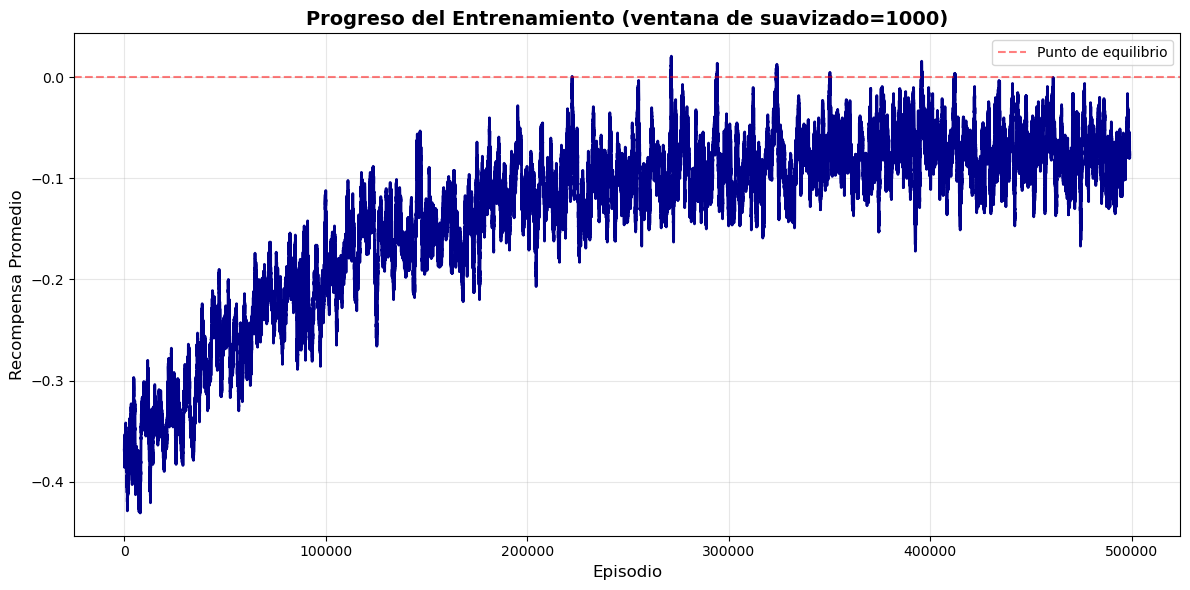


📊 Recompensa promedio final (últimos 1000 episodios): -0.0760


In [ ]:
# Entrenamiento con tu código
num_episodes = 500000
rewards_per_episode = []

print(f"Iniciando entrenamiento con {num_episodes:,} episodios...")
print(f"Hiperparámetros: α={alpha}, γ={gamma}, ε inicial={epsilon}\n")

for episode in tqdm(range(num_episodes), desc="Entrenando"):
    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = choose_action(state, training=True)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Solo añadir a la Q-table si el estado es válido (suma <= 21)
        if next_state not in q_table and next_state[0] <= 21:
            q_table[next_state] = [0, 0]

        # Actualización de Q-Learning (Ecuación de Bellman)
        # Solo actualizar si ambos estados son válidos
        if state in q_table:
            if not done:
                if next_state in q_table:
                    best_next_action = np.argmax(q_table[next_state])
                    q_table[state][action] = q_table[state][action] + alpha * (
                        reward + gamma * q_table[next_state][best_next_action] - q_table[state][action]
                    )
                else:
                    # Si el siguiente estado es inválido (> 21), solo considerar la recompensa
                    q_table[state][action] = q_table[state][action] + alpha * (reward - q_table[state][action])
            else:
                q_table[state][action] = q_table[state][action] + alpha * (reward - q_table[state][action])

        total_reward += reward
        state = next_state

    rewards_per_episode.append(total_reward)

    # Decaimiento progresivo de epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Mostrar progreso
    if (episode + 1) % 100000 == 0:
        recent_avg = np.mean(rewards_per_episode[-10000:])
        print(f"Episodio {episode+1}/{num_episodes}, Epsilon: {epsilon:.5f}, Recompensa promedio: {recent_avg:.4f}")

# Guardar Q-table entrenada
with open("q_table_blackjack_mejorada.pkl", "wb") as f:
    pickle.dump(q_table, f)

print("\n✓ Entrenamiento completado!")
print(f"✓ Q-table guardada en 'q_table_blackjack_mejorada.pkl'")
print(f"✓ Total de estados explorados: {len(q_table)}")

# Promediar las recompensas para graficar
window = 1000
smoothed_rewards = np.convolve(rewards_per_episode, np.ones(window) / window, mode="valid")

# Graficar progreso del entrenamiento
plt.figure(figsize=(12, 6))
plt.plot(smoothed_rewards, linewidth=2, color='darkblue')
plt.xlabel('Episodio', fontsize=12)
plt.ylabel('Recompensa Promedio', fontsize=12)
plt.title(f'Progreso del Entrenamiento (ventana de suavizado={window})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Punto de equilibrio')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 Recompensa promedio final (últimos {window} episodios): {smoothed_rewards[-1]:.4f}")

## 5. Visualización de Resultados

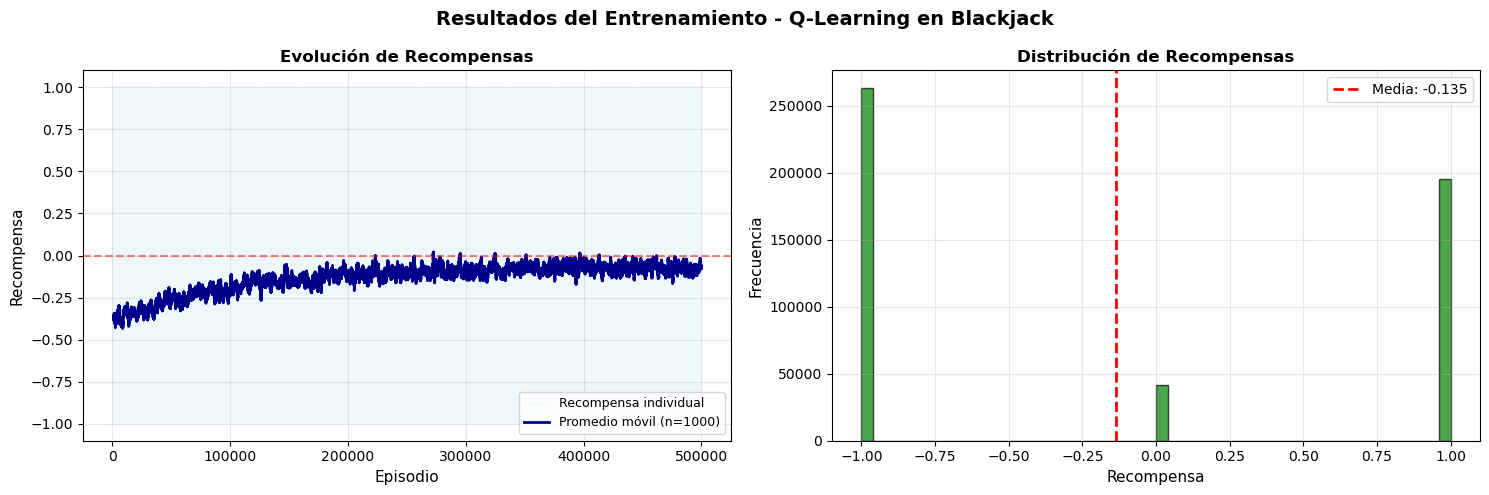


ESTADÍSTICAS DEL ENTRENAMIENTO
Total de episodios:                  500,000
Recompensa promedio:                 -0.1351
Recompensa promedio (últimos 10k):   -0.0792
Desviación estándar:                 0.9482
Recompensa mínima:                   -1.0
Recompensa máxima:                   1.0



In [ ]:
# Visualización simplificada del entrenamiento
def plot_training_simple(rewards, window=1000):
    """
    Visualiza los resultados del entrenamiento de forma simplificada.

    Parámetros:
    -----------
    rewards : list
        Lista de recompensas por episodio
    window : int
        Tamaño de la ventana para el promedio móvil
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Resultados del Entrenamiento - Q-Learning en Blackjack',
                 fontsize=14, fontweight='bold')

    # Gráfico 1: Recompensas
    ax1 = axes[0]
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax1.plot(rewards, alpha=0.2, label='Recompensa individual', color='lightblue', linewidth=0.5)
        ax1.plot(range(window-1, len(rewards)), moving_avg,
                label=f'Promedio móvil (n={window})', color='darkblue', linewidth=2)
    else:
        ax1.plot(rewards, color='blue', linewidth=1)

    ax1.set_xlabel('Episodio', fontsize=11)
    ax1.set_ylabel('Recompensa', fontsize=11)
    ax1.set_title('Evolución de Recompensas', fontsize=12, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)

    # Gráfico 2: Distribución de recompensas
    ax2 = axes[1]
    ax2.hist(rewards, bins=50, color='green', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Recompensa', fontsize=11)
    ax2.set_ylabel('Frecuencia', fontsize=11)
    ax2.set_title('Distribución de Recompensas', fontsize=12, fontweight='bold')
    ax2.axvline(x=np.mean(rewards), color='red', linestyle='--',
                linewidth=2, label=f'Media: {np.mean(rewards):.3f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*70}")
    print("ESTADÍSTICAS DEL ENTRENAMIENTO")
    print(f"{'='*70}")
    print(f"Total de episodios:                  {len(rewards):,}")
    print(f"Recompensa promedio:                 {np.mean(rewards):.4f}")
    print(f"Recompensa promedio (últimos 10k):   {np.mean(rewards[-10000:]):.4f}")
    print(f"Desviación estándar:                 {np.std(rewards):.4f}")
    print(f"Recompensa mínima:                   {np.min(rewards):.1f}")
    print(f"Recompensa máxima:                   {np.max(rewards):.1f}")
    print(f"{'='*70}\n")

# Graficar resultados
plot_training_simple(rewards_per_episode)

## 6. Visualizar la Política Aprendida

La política representa la estrategia óptima: qué acción tomar en cada estado posible del juego.

/tmp/ipykernel_3695/294131565.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


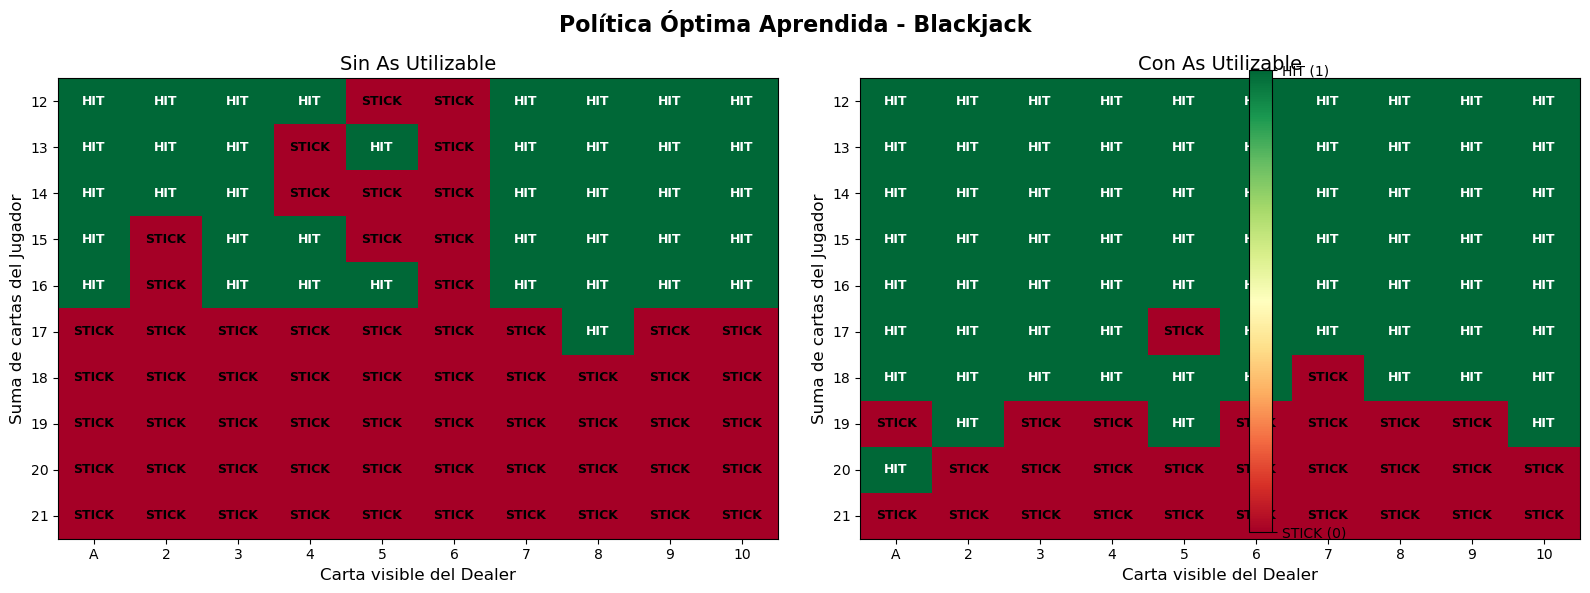


Interpretación de la política:
- Verde (HIT): El agente pide carta
- Rojo (STICK): El agente se planta

Estrategia general observable:
- Con sumas bajas (<17), generalmente pide carta
- Con sumas altas (>17), generalmente se planta
- La decisión varía según la carta del dealer


In [ ]:
def plot_policy(q_table):
    """
    Visualiza la política aprendida como un mapa de calor.

    La política muestra qué acción tomar (pedir carta o plantarse) para cada
    combinación de:
    - Suma de cartas del jugador (eje Y)
    - Carta visible del dealer (eje X)
    - Con o sin As utilizable (dos gráficos separados)

    Parámetros:
    -----------
    q_table : dict
        Tabla Q con los valores aprendidos
    """

    # Crear una matriz para cada caso (con As y sin As)
    # Filas: suma del jugador (12-21)
    # Columnas: carta del dealer (1-10)
    policy_usable_ace = np.zeros((10, 10))
    policy_no_usable_ace = np.zeros((10, 10))

    # Llenar las matrices con la política aprendida
    for player_sum in range(12, 22):  # 12 a 21
        for dealer_card in range(1, 11):  # As(1) a 10
            # Estado con As utilizable
            state_with_ace = (player_sum, dealer_card, 1)
            if state_with_ace in q_table:
                action = np.argmax(q_table[state_with_ace])
                policy_usable_ace[player_sum - 12, dealer_card - 1] = action

            # Estado sin As utilizable
            state_no_ace = (player_sum, dealer_card, 0)
            if state_no_ace in q_table:
                action = np.argmax(q_table[state_no_ace])
                policy_no_usable_ace[player_sum - 12, dealer_card - 1] = action

    # Crear visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Política Óptima Aprendida - Blackjack', fontsize=16, fontweight='bold')

    # Etiquetas para los ejes
    player_labels = list(range(12, 22))  # 12-21
    dealer_labels = ['A', '2', '3', '4', '5', '6', '7', '8', '9', '10']

    # Gráfico 1: Sin As utilizable
    im1 = ax1.imshow(policy_no_usable_ace, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax1.set_xticks(range(10))
    ax1.set_yticks(range(10))
    ax1.set_xticklabels(dealer_labels)
    ax1.set_yticklabels(player_labels)
    ax1.set_xlabel('Carta visible del Dealer', fontsize=12)
    ax1.set_ylabel('Suma de cartas del Jugador', fontsize=12)
    ax1.set_title('Sin As Utilizable', fontsize=14)

    # Añadir texto en cada celda
    for i in range(10):
        for j in range(10):
            action = int(policy_no_usable_ace[i, j])
            text = 'HIT' if action == 1 else 'STICK'
            color = 'white' if action == 1 else 'black'
            ax1.text(j, i, text, ha='center', va='center',
                    color=color, fontweight='bold', fontsize=9)

    # Gráfico 2: Con As utilizable
    im2 = ax2.imshow(policy_usable_ace, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax2.set_xticks(range(10))
    ax2.set_yticks(range(10))
    ax2.set_xticklabels(dealer_labels)
    ax2.set_yticklabels(player_labels)
    ax2.set_xlabel('Carta visible del Dealer', fontsize=12)
    ax2.set_ylabel('Suma de cartas del Jugador', fontsize=12)
    ax2.set_title('Con As Utilizable', fontsize=14)

    # Añadir texto en cada celda
    for i in range(10):
        for j in range(10):
            action = int(policy_usable_ace[i, j])
            text = 'HIT' if action == 1 else 'STICK'
            color = 'white' if action == 1 else 'black'
            ax2.text(j, i, text, ha='center', va='center',
                    color=color, fontweight='bold', fontsize=9)

    # Añadir barra de color
    cbar = plt.colorbar(im2, ax=[ax1, ax2], orientation='vertical', pad=0.02)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['STICK (0)', 'HIT (1)'])

    plt.tight_layout()
    plt.show()

    print("\nInterpretación de la política:")
    print("- Verde (HIT): El agente pide carta")
    print("- Rojo (STICK): El agente se planta")
    print("\nEstrategia general observable:")
    print("- Con sumas bajas (<17), generalmente pide carta")
    print("- Con sumas altas (>17), generalmente se planta")
    print("- La decisión varía según la carta del dealer")

# Visualizar la política
plot_policy(q_table)

## 7. Evaluación del Agente Entrenado

Probemos el agente entrenado en partidas de prueba para ver su desempeño.

In [ ]:
def evaluate_agent_simple(env, q_table, n_episodes=10000):
    """
    Evalúa el rendimiento del agente entrenado sin exploración.

    Durante la evaluación:
    - El agente siempre elige la mejor acción conocida (sin exploración)
    - No actualiza la tabla Q
    - Se mide el rendimiento real de la política aprendida

    Parámetros:
    -----------
    env : gym.Env
        Entorno de Blackjack
    q_table : dict
        Tabla Q entrenada
    n_episodes : int
        Número de episodios de evaluación

    Returns:
    --------
    dict : Diccionario con métricas de rendimiento
    """

    # Contadores de resultados
    wins = 0
    losses = 0
    draws = 0
    total_reward = 0

    # Estadísticas adicionales
    episode_rewards = []
    episode_lengths = []

    print(f"\n{'='*70}")
    print(f"EVALUACIÓN DEL AGENTE ENTRENADO")
    print(f"{'='*70}")
    print(f"Evaluando en {n_episodes:,} partidas...")
    print(f"Modo: Explotación pura (sin exploración)\n")

    # Evaluar el agente
    for episode in tqdm(range(n_episodes), desc="Evaluando", ncols=100):
        state, info = env.reset()
        done = False
        episode_reward = 0
        episode_length = 0

        # Jugar un episodio completo
        while not done:
            # Usar la política aprendida (elegir la mejor acción)
            if state in q_table:
                action = np.argmax(q_table[state])
            else:
                # Si el estado no fue explorado, usar una estrategia por defecto
                action = 0 if state[0] >= 17 else 1  # Plantarse con 17+

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            state = next_state
            episode_reward += reward
            episode_length += 1

        # Acumular estadísticas
        total_reward += episode_reward
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)

        # Clasificar resultado
        if episode_reward > 0:
            wins += 1
        elif episode_reward < 0:
            losses += 1
        else:
            draws += 1

    # Calcular métricas
    win_rate = wins / n_episodes
    loss_rate = losses / n_episodes
    draw_rate = draws / n_episodes
    avg_reward = total_reward / n_episodes
    avg_length = np.mean(episode_lengths)

    # Imprimir resultados detallados
    print(f"\n{'='*70}")
    print(f"RESULTADOS DE EVALUACIÓN")
    print(f"{'='*70}")
    print(f"Partidas jugadas: {n_episodes:,}\n")
    print(f"Distribución de Resultados:")
    print(f"  Victorias: {wins:>7,} ({win_rate:>6.2%})  {'█' * int(win_rate * 50)}")
    print(f"  Derrotas:  {losses:>7,} ({loss_rate:>6.2%})  {'█' * int(loss_rate * 50)}")
    print(f"  Empates:   {draws:>7,} ({draw_rate:>6.2%})  {'█' * int(draw_rate * 50)}")
    print(f"\nMétricas de Rendimiento:")
    print(f"  Recompensa promedio:           {avg_reward:>7.4f}")
    print(f"  Longitud promedio de partida:  {avg_length:>7.2f} pasos")
    print(f"  Desviación estándar recompensa: {np.std(episode_rewards):>7.4f}")
    print(f"{'='*70}")

    # Comparación con estrategia aleatoria
    random_win_rate = 0.28  # Tasa de victoria aproximada de jugador aleatorio
    improvement = (win_rate - random_win_rate) / random_win_rate * 100

    print(f"\n{'='*70}")
    print(f"COMPARACIÓN CON ESTRATEGIA ALEATORIA")
    print(f"{'='*70}")
    print(f"Agente entrenado (Q-Learning):  {win_rate:>6.2%} de victorias")
    print(f"Jugador aleatorio (baseline):   {random_win_rate:>6.2%} de victorias")
    print(f"Mejora relativa:                {improvement:>+6.1f}%")

    # Análisis cualitativo
    if improvement > 40:
        performance = "EXCELENTE ✓✓✓"
    elif improvement > 30:
        performance = "MUY BUENO ✓✓"
    elif improvement > 20:
        performance = "BUENO ✓"
    elif improvement > 10:
        performance = "ACEPTABLE"
    else:
        performance = "NECESITA MEJORA"

    print(f"Evaluación cualitativa:         {performance}")
    print(f"{'='*70}\n")

    # Retornar métricas completas
    return {
        'wins': wins,
        'losses': losses,
        'draws': draws,
        'win_rate': win_rate,
        'loss_rate': loss_rate,
        'draw_rate': draw_rate,
        'avg_reward': avg_reward,
        'avg_length': avg_length,
        'std_reward': np.std(episode_rewards),
        'improvement': improvement,
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths
    }

# Evaluar el agente
eval_results = evaluate_agent_simple(env, q_table, n_episodes=10000)


EVALUACIÓN DEL AGENTE ENTRENADO
Evaluando en 10,000 partidas...
Modo: Explotación pura (sin exploración)



Evaluando: 100%|███████████████████████████████████████████| 10000/10000 [00:00<00:00, 11741.52it/s]


RESULTADOS DE EVALUACIÓN
Partidas jugadas: 10,000

Distribución de Resultados:
  Victorias:   4,099 (40.99%)  ████████████████████
  Derrotas:    4,922 (49.22%)  ████████████████████████
  Empates:       979 ( 9.79%)  ████

Métricas de Rendimiento:
  Recompensa promedio:           -0.0823
  Longitud promedio de partida:     1.61 pasos
  Desviación estándar recompensa:  0.9462

COMPARACIÓN CON ESTRATEGIA ALEATORIA
Agente entrenado (Q-Learning):  40.99% de victorias
Jugador aleatorio (baseline):   28.00% de victorias
Mejora relativa:                 +46.4%
Evaluación cualitativa:         EXCELENTE ✓✓✓



## 8. Demostración de Partidas Individuales

Veamos algunos ejemplos de cómo juega el agente entrenado.

In [ ]:
def play_demo_game(env, q_table, n_games=5):
    """
    Juega y muestra partidas de demostración del agente.

    Parámetros:
    -----------
    env : gym.Env
        Entorno de Blackjack
    q_table : dict
        Tabla Q entrenada
    n_games : int
        Número de partidas a mostrar
    """

    action_names = {0: "PLANTARSE", 1: "PEDIR CARTA"}

    for game_num in range(n_games):
        print("\n" + "="*60)
        print(f"PARTIDA #{game_num + 1}")
        print("="*60)

        state, info = env.reset()
        done = False
        step = 0

        print(f"\n🎴 Estado inicial:")
        print(f"   Cartas del jugador: {state[0]}")
        print(f"   Carta visible del dealer: {state[1]}")
        print(f"   Tiene As utilizable: {'Sí' if state[2] else 'No'}")

        # Jugar el episodio
        while not done:
            step += 1

            # Obtener acción del agente (sin exploración)
            if state in q_table:
                action = np.argmax(q_table[state])
            else:
                action = 0 if state[0] >= 17 else 1  # Estrategia por defecto

            # Mostrar decisión
            print(f"\n   Paso {step}: {action_names[action]}")

            # Ejecutar acción
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Si se pidió carta, mostrar el nuevo estado
            if action == 1 and not done:
                print(f"   Nueva suma: {next_state[0]}")
                print(f"   Tiene As utilizable: {'Sí' if next_state[2] else 'No'}")

            state = next_state

        # Mostrar resultado final
        print(f"\n🎯 RESULTADO:")
        if reward > 0:
            print(f"   ✅ VICTORIA! El jugador gana")
        elif reward < 0:
            print(f"   ❌ DERROTA! El dealer gana")
        else:
            print(f"   🤝 EMPATE!")

        print(f"   Suma final del jugador: {state[0]}")
        print(f"   Recompensa: {reward:+.1f}")
        print("="*60)

# Jugar algunas partidas de demostración
play_demo_game(env, q_table, n_games=5)


PARTIDA #1

🎴 Estado inicial:
   Cartas del jugador: 20
   Carta visible del dealer: 5
   Tiene As utilizable: Sí

   Paso 1: PLANTARSE

🎯 RESULTADO:
   ✅ VICTORIA! El jugador gana
   Suma final del jugador: 20
   Recompensa: +1.0

PARTIDA #2

🎴 Estado inicial:
   Cartas del jugador: 11
   Carta visible del dealer: 9
   Tiene As utilizable: No

   Paso 1: PEDIR CARTA
   Nueva suma: 17
   Tiene As utilizable: No

   Paso 2: PLANTARSE

🎯 RESULTADO:
   🤝 EMPATE!
   Suma final del jugador: 17
   Recompensa: +0.0

PARTIDA #3

🎴 Estado inicial:
   Cartas del jugador: 20
   Carta visible del dealer: 8
   Tiene As utilizable: No

   Paso 1: PLANTARSE

🎯 RESULTADO:
   ❌ DERROTA! El dealer gana
   Suma final del jugador: 20
   Recompensa: -1.0

PARTIDA #4

🎴 Estado inicial:
   Cartas del jugador: 12
   Carta visible del dealer: 10
   Tiene As utilizable: Sí

   Paso 1: PEDIR CARTA
   Nueva suma: 15
   Tiene As utilizable: Sí

   Paso 2: PEDIR CARTA
   Nueva suma: 15
   Tiene As utilizable: No



## 9. Análisis de los Valores Q

Veamos los valores Q aprendidos para entender mejor las decisiones del agente.

In [ ]:
def analyze_q_values(q_table, sample_states=10):
    """
    Analiza y muestra los valores Q para estados de ejemplo.

    Parámetros:
    -----------
    q_table : dict
        Tabla Q entrenada
    sample_states : int
        Número de estados de ejemplo a mostrar
    """

    print("ANÁLISIS DE VALORES Q")
    print("="*70)
    print("\nLos valores Q representan la recompensa esperada para cada acción.")
    print("Valores más altos indican acciones más prometedoras.\n")

    # Seleccionar algunos estados interesantes
    interesting_states = [
        (12, 2, 0),   # Suma baja, carta baja del dealer
        (16, 7, 0),   # Suma media, carta media del dealer
        (18, 10, 0),  # Suma alta, carta alta del dealer
        (20, 6, 0),   # Suma muy alta
        (12, 10, 1),  # Con As utilizable
        (17, 1, 1),   # 17 con As, dealer muestra As
        (14, 5, 0),   # Estado común
        (19, 8, 0),   # Casi 21
        (13, 3, 1),   # Suma baja con As
        (15, 9, 0),   # Suma media, dealer fuerte
    ]

    print(f"{'Estado':^30} | {'Q(STICK)':>12} | {'Q(HIT)':>12} | {'Mejor Acción':^15}")
    print("-" * 70)

    for state in interesting_states:
        player_sum, dealer_card, usable_ace = state

        if state in q_table:
            q_values = q_table[state]
            q_stick = q_values[0]
            q_hit = q_values[1]
            best_action = "STICK" if q_stick > q_hit else "HIT"

            # Formatear el estado
            ace_str = " (As)" if usable_ace else ""
            state_str = f"J:{player_sum}{ace_str}, D:{dealer_card}"

            print(f"{state_str:^30} | {q_stick:>12.4f} | {q_hit:>12.4f} | {best_action:^15}")
        else:
            state_str = f"J:{player_sum}, D:{dealer_card}, As:{usable_ace}"
            print(f"{state_str:^30} | {'No visitado':^27} | {'N/A':^15}")

    print("="*70)

    # Estadísticas generales de la tabla Q
    print("\n📊 ESTADÍSTICAS DE LA TABLA Q:")
    print(f"   Total de estados explorados: {len(q_table)}")

    # Calcular el valor promedio de cada acción
    avg_q_stick = np.mean([q[0] for q in q_table.values()])
    avg_q_hit = np.mean([q[1] for q in q_table.values()])

    print(f"   Valor Q promedio (STICK): {avg_q_stick:.4f}")
    print(f"   Valor Q promedio (HIT): {avg_q_hit:.4f}")

    # Contar cuántas veces se prefiere cada acción
    stick_count = sum(1 for q in q_table.values() if q[0] > q[1])
    hit_count = sum(1 for q in q_table.values() if q[1] > q[0])

    print(f"   Estados donde se prefiere STICK: {stick_count} ({stick_count/len(q_table)*100:.1f}%)")
    print(f"   Estados donde se prefiere HIT: {hit_count} ({hit_count/len(q_table)*100:.1f}%)")
    print("="*70)

# Analizar valores Q
analyze_q_values(q_table)

ANÁLISIS DE VALORES Q

Los valores Q representan la recompensa esperada para cada acción.
Valores más altos indican acciones más prometedoras.

            Estado             |     Q(STICK) |       Q(HIT) |  Mejor Acción  
----------------------------------------------------------------------
          J:12, D:2            |      -0.8224 |      -0.3166 |       HIT      
          J:16, D:7            |      -0.6491 |      -0.2594 |       HIT      
          J:18, D:10           |      -0.4929 |      -0.7955 |      STICK     
          J:20, D:6            |       0.5709 |      -0.9233 |      STICK     
       J:12 (As), D:10         |      -0.7687 |       0.0133 |       HIT      
        J:17 (As), D:1         |      -0.5943 |      -0.3220 |       HIT      
          J:14, D:5            |      -0.0411 |      -0.6291 |      STICK     
          J:19, D:8            |       0.4818 |      -0.8910 |      STICK     
        J:13 (As), D:3         |      -0.2134 |      -0.0530 |       HIT  

## 10. Comparación con Estrategia Básica de Blackjack

La estrategia básica de Blackjack es una estrategia matemáticamente óptima basada en probabilidades.
Vamos a compararla con la política aprendida por nuestro agente Q-Learning.


EVALUACIÓN DE ESTRATEGIA BÁSICA

Evaluando Estrategia Básica en 10,000 partidas...


Evaluando Estrategia Básica: 100%|█████████████████████████| 10000/10000 [00:00<00:00, 14174.28it/s]


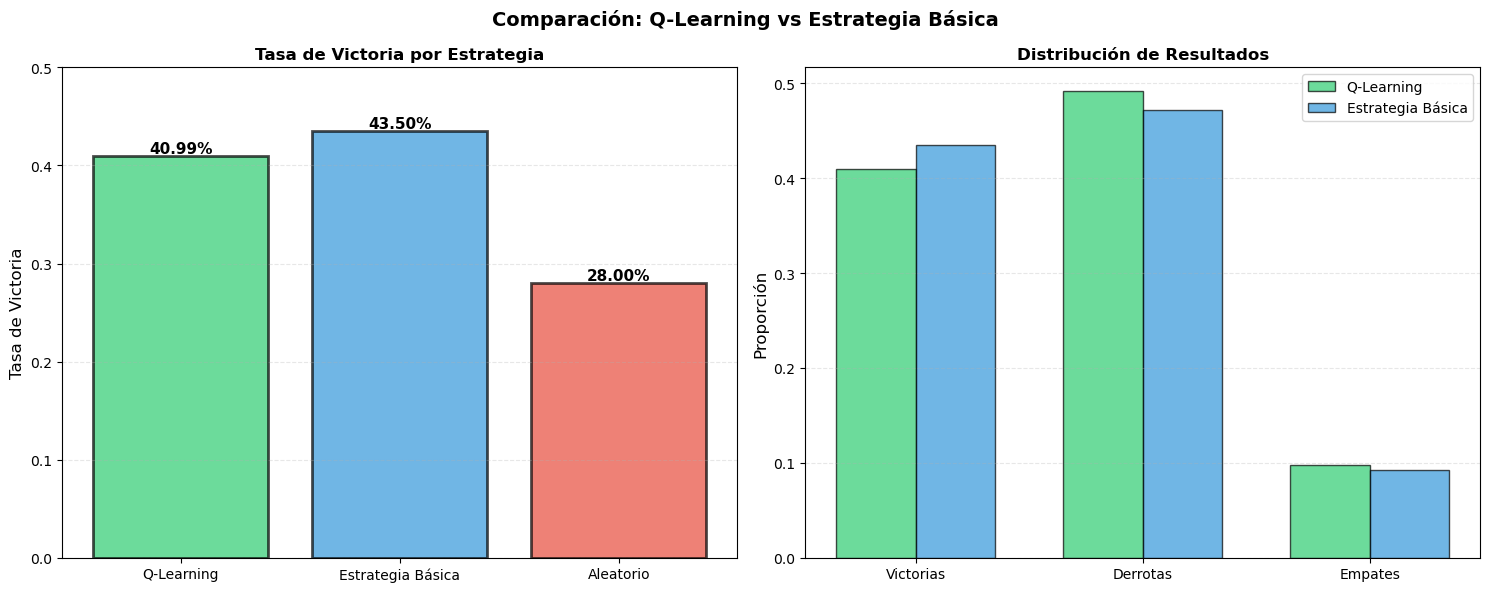


ANÁLISIS COMPARATIVO DE ESTRATEGIAS

Métrica                             Q-Learning    Estrategia Básica
----------------------------------------------------------------------
Tasa de Victoria                       40.99%               43.50%
Recompensa Promedio                   -0.0823              -0.0371
Victorias                                4,099                4,350
Derrotas                                 4,922                4,721
Empates                                    979                  929

✗ La estrategia básica supera al agente Q-Learning en +6.12%



In [ ]:
def basic_strategy_agent(state):
    """
    Implementa la estrategia básica simplificada de Blackjack.

    Esta es una estrategia conservadora basada en probabilidades:
    - Con As utilizable: más agresivo (pedir hasta 18)
    - Sin As utilizable: más conservador (pedir hasta 17)
    - Considera la carta visible del dealer

    Parámetros:
    -----------
    state : tuple
        (suma_jugador, carta_dealer, as_utilizable)

    Returns:
    --------
    int : 0=plantarse, 1=pedir carta
    """
    player_sum, dealer_card, usable_ace = state

    # Estrategia con As utilizable (más agresivo)
    if usable_ace:
        # Con As flexible, puedes arriesgar más
        if player_sum < 18:
            return 1  # HIT
        else:
            return 0  # STICK

    # Estrategia sin As utilizable
    else:
        # Siempre pedir con menos de 12 (no hay riesgo de pasarse)
        if player_sum < 12:
            return 1  # HIT

        # Entre 12 y 16: depende de la carta del dealer
        elif player_sum <= 16:
            # Si el dealer muestra carta débil (2-6), plantarse
            if 2 <= dealer_card <= 6:
                return 0  # STICK
            else:
                return 1  # HIT

        # Con 17 o más, siempre plantarse
        else:
            return 0  # STICK


def evaluate_basic_strategy(env, n_episodes=10000):
    """
    Evalúa el rendimiento de la estrategia básica.

    Parámetros:
    -----------
    env : gym.Env
        Entorno de Blackjack
    n_episodes : int
        Número de episodios de evaluación

    Returns:
    --------
    dict : Métricas de rendimiento
    """
    wins = 0
    losses = 0
    draws = 0
    total_reward = 0

    print(f"\nEvaluando Estrategia Básica en {n_episodes:,} partidas...")

    for _ in tqdm(range(n_episodes), desc="Evaluando Estrategia Básica", ncols=100):
        state, _ = env.reset()
        done = False
        episode_reward = 0

        while not done:
            action = basic_strategy_agent(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward

        total_reward += episode_reward
        if episode_reward > 0:
            wins += 1
        elif episode_reward < 0:
            losses += 1
        else:
            draws += 1

    win_rate = wins / n_episodes

    return {
        'wins': wins,
        'losses': losses,
        'draws': draws,
        'win_rate': win_rate,
        'avg_reward': total_reward / n_episodes
    }


def compare_strategies(agent_results, basic_results):
    """
    Compara visualmente el rendimiento de ambas estrategias.

    Parámetros:
    -----------
    agent_results : dict
        Resultados del agente Q-Learning
    basic_results : dict
        Resultados de la estrategia básica
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Comparación: Q-Learning vs Estrategia Básica',
                 fontsize=14, fontweight='bold')

    # ========== Gráfico 1: Tasa de Victoria ==========
    ax1 = axes[0]
    strategies = ['Q-Learning', 'Estrategia Básica', 'Aleatorio']
    win_rates = [
        agent_results['win_rate'],
        basic_results['win_rate'],
        0.28  # Referencia aleatoria
    ]
    colors = ['#2ecc71', '#3498db', '#e74c3c']

    bars = ax1.bar(strategies, win_rates, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax1.set_ylabel('Tasa de Victoria', fontsize=12)
    ax1.set_title('Tasa de Victoria por Estrategia', fontsize=12, fontweight='bold')
    ax1.set_ylim([0, 0.5])
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    # Agregar valores sobre las barras
    for bar, rate in zip(bars, win_rates):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{rate:.2%}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # ========== Gráfico 2: Distribución de Resultados ==========
    ax2 = axes[1]

    categories = ['Victorias', 'Derrotas', 'Empates']
    agent_dist = [agent_results['win_rate'], agent_results['loss_rate'], agent_results['draw_rate']]
    basic_dist = [basic_results['win_rate'], basic_results['losses']/10000, basic_results['draws']/10000]

    x = np.arange(len(categories))
    width = 0.35

    bars1 = ax2.bar(x - width/2, agent_dist, width, label='Q-Learning',
                   color='#2ecc71', alpha=0.7, edgecolor='black')
    bars2 = ax2.bar(x + width/2, basic_dist, width, label='Estrategia Básica',
                   color='#3498db', alpha=0.7, edgecolor='black')

    ax2.set_ylabel('Proporción', fontsize=12)
    ax2.set_title('Distribución de Resultados', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(categories)
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

    # ========== Análisis Comparativo ==========
    print("\n" + "="*70)
    print("ANÁLISIS COMPARATIVO DE ESTRATEGIAS")
    print("="*70)
    print(f"\n{'Métrica':<30} {'Q-Learning':>15} {'Estrategia Básica':>20}")
    print("-"*70)
    print(f"{'Tasa de Victoria':<30} {agent_results['win_rate']:>14.2%} {basic_results['win_rate']:>20.2%}")
    print(f"{'Recompensa Promedio':<30} {agent_results['avg_reward']:>14.4f} {basic_results['avg_reward']:>20.4f}")
    print(f"{'Victorias':<30} {agent_results['wins']:>15,} {basic_results['wins']:>20,}")
    print(f"{'Derrotas':<30} {agent_results['losses']:>15,} {basic_results['losses']:>20,}")
    print(f"{'Empates':<30} {agent_results['draws']:>15,} {basic_results['draws']:>20,}")
    print("="*70)

    # Determinar ganador
    if agent_results['win_rate'] > basic_results['win_rate']:
        diff = (agent_results['win_rate'] - basic_results['win_rate']) / basic_results['win_rate'] * 100
        print(f"\n✓ El agente Q-Learning SUPERA la estrategia básica en {diff:+.2f}%")
    elif agent_results['win_rate'] < basic_results['win_rate']:
        diff = (basic_results['win_rate'] - agent_results['win_rate']) / agent_results['win_rate'] * 100
        print(f"\n✗ La estrategia básica supera al agente Q-Learning en {diff:+.2f}%")
    else:
        print(f"\n≈ Ambas estrategias tienen rendimiento similar")

    print("="*70 + "\n")


# Evaluar estrategia básica
print("\n" + "="*70)
print("EVALUACIÓN DE ESTRATEGIA BÁSICA")
print("="*70)
basic_results = evaluate_basic_strategy(env, n_episodes=10000)

# Comparar con el agente Q-Learning
compare_strategies(eval_results, basic_results)

## Resumen del Notebook

Este notebook implementó un agente de **Q-Learning** para jugar Blackjack usando **Gymnasium**. Los componentes principales fueron:

### Componentes Implementados:

1. **Entorno Blackjack**: Simulador del juego con estados y acciones discretas
2. **Agente Q-Learning**:
   - Tabla Q para almacenar valores estado-acción
   - Política epsilon-greedy para exploración/explotación
   - Actualización de valores usando Temporal Difference (TD)
3. **Entrenamiento**: Loop de episodios con actualización incremental de la tabla Q
4. **Evaluación**: Métricas de rendimiento y comparación con estrategia aleatoria
5. **Visualización**: Gráficos de aprendizaje y mapa de la política óptima

### Conceptos Clave de Reinforcement Learning:

- **Estado (State)**: Situación actual del juego
- **Acción (Action)**: Decisión a tomar (hit/stick)
- **Recompensa (Reward)**: Feedback del entorno (+1, 0, -1)
- **Política (Policy)**: Estrategia de qué acción tomar en cada estado
- **Valor Q**: Utilidad esperada de tomar una acción en un estado
- **Exploración vs Explotación**: Balance entre probar nuevas acciones y usar conocimiento adquirido

### Extensiones Posibles:

- Implementar otros algoritmos (SARSA, Deep Q-Network)
- Probar otros entornos de Gymnasium (CartPole, MountainCar, etc.)
- Añadir técnicas avanzadas (Experience Replay, Target Networks)
- Comparar con estrategias óptimas conocidas de Blackjack